# Phase 1 - Project Setup and Dataset Audit

This notebook performs:

- Google Drive mounting
- project root creation
- persistent directory creation
- config-driven setup
- classification dataset audit
- detection dataset audit
- sample image visualization
- audit report generation

All outputs are saved inside Google Drive-backed paths.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

ModuleNotFoundError: No module named 'google.colab'

In [72]:
from pathlib import Path
import sys

PROJECT_NAME = "Aerial_Object_Classification_Detection"
PROJECT_ROOT = Path("/content/drive/MyDrive") / PROJECT_NAME
PROJECT_ROOT

PosixPath('/content/drive/MyDrive/Aerial_Object_Classification_Detection')

In [73]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: /content/drive/MyDrive/Aerial_Object_Classification_Detection


In [74]:
from src.utils.paths import build_project_paths, create_project_directories
from src.utils.logger import get_logger
from src.utils.config import load_yaml
from src.utils.seed import set_seed
from src.utils.io import save_text, save_dataframe
from src.utils.plotting import plot_image_grid
from src.data.dataset_audit import (
    inspect_folder_structure,
    count_classification_images_by_split_and_class,
    collect_non_jpg_files,
    get_sample_images,
    build_classification_audit_summary,
    export_audited_classification_dataset,
    build_processed_export_summary,
)
from src.data.detection_loader import count_detection_split_files
from src.data.validate_detection_labels import (
    validate_detection_dataset,
    overlay_yolo_boxes_on_image,
    image_to_label_path,
)


In [75]:
set_seed(42)

paths = build_project_paths(PROJECT_ROOT)
create_project_directories(paths)

logger = get_logger(
    name="phase1_dataset_audit",
    log_file=paths["logs_dir"] / "phase1_dataset_audit.log",
)

logger.info("Project directories created successfully.")

2026-03-27 19:19:23 | INFO | phase1_dataset_audit | Project directories created successfully.


In [76]:
import yaml

paths_yaml_path = PROJECT_ROOT / "configs" / "paths.yaml"
classification_config_path = PROJECT_ROOT / "configs" / "classification_config.yaml"
detection_config_path = PROJECT_ROOT / "configs" / "detection_config.yaml"

paths_config = load_yaml(paths_yaml_path)
classification_config = load_yaml(classification_config_path)
detection_config = load_yaml(detection_config_path)

logger.info("Configs loaded successfully.")

2026-03-27 19:19:23 | INFO | phase1_dataset_audit | Configs loaded successfully.


## 1. Classification Dataset Audit
We inspect:
- folder structure
- train/valid/test split
- class names
- image counts
- file extensions

In [77]:
classification_root = Path(paths_config["paths"]["classification_dataset"])

classification_structure = inspect_folder_structure(classification_root)
classification_structure

{'test': ['bird', 'drone'],
 'train': ['bird', 'drone'],
 'valid': ['bird', 'drone']}

In [78]:
expected_splits = classification_config["dataset"]["expected_splits"]
expected_classes = classification_config["dataset"]["expected_classes"]
expected_extension = classification_config["dataset"]["expected_extension"]

classification_counts_df = count_classification_images_by_split_and_class(
    dataset_root=classification_root,
    expected_splits=expected_splits,
    expected_classes=expected_classes,
    extension=expected_extension,
)

classification_counts_df

,split,class_name,image_count
0,train,bird,1414
1,train,drone,1248
2,valid,bird,217
3,valid,drone,225
4,test,bird,121
5,test,drone,94


In [79]:
non_jpg_files = collect_non_jpg_files(classification_root)
print(f"Non-JPG files found: {len(non_jpg_files)}")
non_jpg_files[:10]

Non-JPG files found: 0


[]

In [80]:
classification_summary_md = build_classification_audit_summary(
    counts_df=classification_counts_df,
    non_jpg_files=non_jpg_files,
    expected_classes=expected_classes,
)

print(classification_summary_md[:1500])

# Classification Dataset Audit Summary

- Expected classes: ['bird', 'drone']
- Found classes: ['bird', 'drone']
- Total counted .jpg images: 3319
- Non-.jpg files found: 0

## Split-wise counts

| split   | class_name   |   image_count |
|:--------|:-------------|--------------:|
| train   | bird         |          1414 |
| train   | drone        |          1248 |
| valid   | bird         |           217 |
| valid   | drone        |           225 |
| test    | bird         |           121 |
| test    | drone        |            94 |


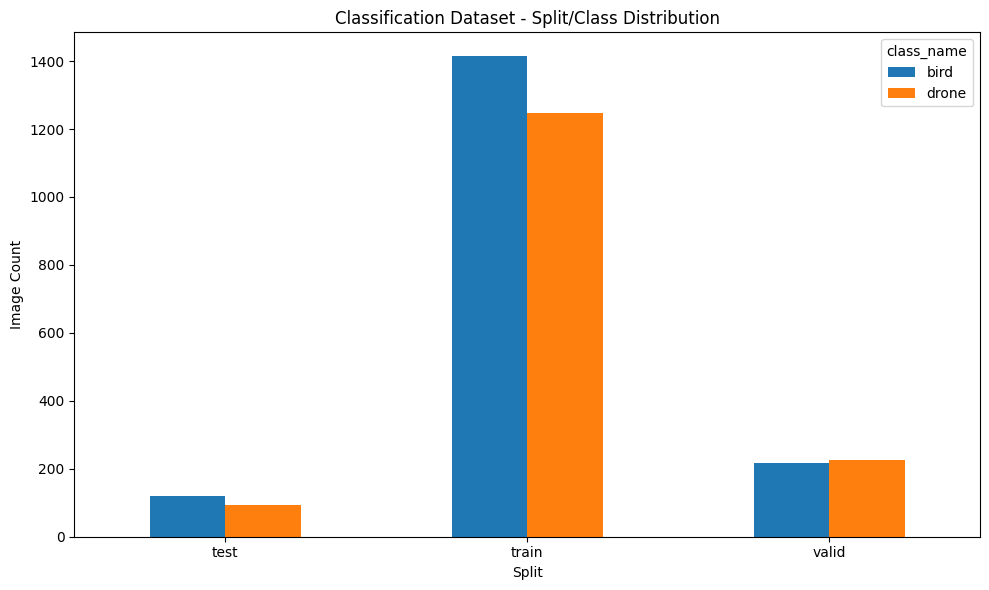

In [81]:
import matplotlib.pyplot as plt
import pandas as pd

pivot_df = classification_counts_df.pivot(index="split", columns="class_name", values="image_count")
pivot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Classification Dataset - Split/Class Distribution")
plt.xlabel("Split")
plt.ylabel("Image Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(paths["figures_dataset_audit_dir"] / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [83]:
bird_train_dir = classification_root / "train" / "bird"
drone_train_dir = classification_root / "train" / "drone"

bird_samples = get_sample_images(
    class_dir=bird_train_dir,
    n_samples=classification_config["audit"]["sample_images_per_class"],
    seed=classification_config["audit"]["random_seed"],
)

drone_samples = get_sample_images(
    class_dir=drone_train_dir,
    n_samples=classification_config["audit"]["sample_images_per_class"],
    seed=classification_config["audit"]["random_seed"],
)

print("Bird samples:", len(bird_samples))
print("Drone samples:", len(drone_samples))

Bird samples: 8
Drone samples: 8


In [86]:
plot_image_grid(
    image_paths=bird_samples,
    title="Bird Sample Images",
    output_path=paths["figures_dataset_audit_dir"] / "bird_samples.png",
    ncols=4,
    figsize=(16, 8),
    dpi=150,
)

In [87]:
plot_image_grid(
    image_paths=drone_samples,
    title="Drone Sample Images",
    output_path=paths["figures_dataset_audit_dir"] / "drone_samples.png",
    ncols=4,
    figsize=(16, 8),
    dpi=150,
)

## 2. Detection Dataset Audit
We inspect:
- split structure
- image and label folders
- image-label pairing
- YOLO annotation format
- sample overlays

In [88]:
detection_root = Path(paths_config["paths"]["object_detection_dataset"])
detection_splits = detection_config["dataset"]["expected_splits"]

detection_counts_df = count_detection_split_files(
    dataset_root=detection_root,
    splits=detection_splits,
)

detection_counts_df

,split,image_dir_exists,label_dir_exists,image_count,label_count
0,train,True,True,2728,2728
1,valid,True,True,448,448
2,test,True,True,224,224


In [89]:
detection_validation_df = validate_detection_dataset(
    dataset_root=detection_root,
    splits=detection_splits,
)

detection_validation_df.head()

,split,file_type,file_path,issue,is_valid
0,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,OK,True
1,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,OK,True
2,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,OK,True
3,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,OK,True
4,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,OK,True


In [90]:
invalid_rows = detection_validation_df[detection_validation_df["is_valid"] == False]
print(f"Invalid detection records: {len(invalid_rows)}")
invalid_rows.head(20)

Invalid detection records: 81


,split,file_type,file_path,issue,is_valid
2600,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,Empty label file,False
2605,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,Empty label file,False
2628,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,Empty label file,False
2629,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,Empty label file,False
2638,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,Empty label file,False
2639,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,Empty label file,False
2666,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,Empty label file,False
2667,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,Empty label file,False
2668,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,Empty label file,False
2669,train,label,/content/drive/MyDrive/Aerial_Object_Classific...,Empty label file,False


In [91]:
from pathlib import Path
import matplotlib.pyplot as plt

sample_detection_images = sorted((detection_root / "train" / "images").glob("*.jpg"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, sample_detection_images):
    label_path = image_to_label_path(image_path)
    image_rgb = overlay_yolo_boxes_on_image(image_path, label_path)
    ax.imshow(image_rgb)
    ax.set_title(image_path.name, fontsize=9)
    ax.axis("off")

for ax in axes[len(sample_detection_images):]:
    ax.axis("off")

plt.suptitle("Detection Sample Images with YOLO Box Overlays", fontsize=16)
plt.tight_layout()
plt.savefig(paths["figures_dataset_audit_dir"] / "detection_samples.png", dpi=150, bbox_inches="tight")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [92]:
detection_summary_lines = []
detection_summary_lines.append("# Detection Dataset Audit Summary")
detection_summary_lines.append("")
detection_summary_lines.append("## Split Counts")
detection_summary_lines.append("")
detection_summary_lines.append(detection_counts_df.to_markdown(index=False))
detection_summary_lines.append("")
detection_summary_lines.append("## Validation Summary")
detection_summary_lines.append("")
detection_summary_lines.append(f"- Total validation rows: {len(detection_validation_df)}")
detection_summary_lines.append(f"- Invalid rows: {len(invalid_rows)}")

detection_summary_md = "\n".join(detection_summary_lines)
print(detection_summary_md)

# Detection Dataset Audit Summary

## Split Counts

| split   | image_dir_exists   | label_dir_exists   |   image_count |   label_count |
|:--------|:-------------------|:-------------------|--------------:|--------------:|
| train   | True               | True               |          2728 |          2728 |
| valid   | True               | True               |           448 |           448 |
| test    | True               | True               |           224 |           224 |

## Validation Summary

- Total validation rows: 4940
- Invalid rows: 81


In [93]:
full_report = "\n\n".join(
    [
        classification_summary_md,
        detection_summary_md,
        "\n## Notes\n- Binary classes confirmed as Bird and Drone if folder names match exactly.\n- All critical outputs are saved under Drive-backed folders.\n"
    ]
)

save_text(full_report, paths["reports_dir"] / "dataset_audit_report.md")
save_dataframe(classification_counts_df, paths["dataset_audit_dir"] / "classification_counts.csv")
save_dataframe(detection_counts_df, paths["dataset_audit_dir"] / "detection_split_counts.csv")
save_dataframe(detection_validation_df, paths["label_checks_dir"] / "detection_label_validation.csv")

logger.info("Dataset audit artifacts saved successfully.")
print("Report saved:", paths["reports_dir"] / "dataset_audit_report.md")

2026-03-27 20:22:07 | INFO | phase1_dataset_audit | Dataset audit artifacts saved successfully.


Report saved: /content/drive/MyDrive/Aerial_Object_Classification_Detection/reports/dataset_audit_report.md


## Export audited classification dataset to processed

This section copies only audited-valid `.jpg` classification images from the raw dataset into:

- `data/processed/classification/train/...`
- `data/processed/classification/valid/...`
- `data/processed/classification/test/...`

It preserves the split/class folder structure and skips invalid files.

In [ ]:
processed_classification_root = PROJECT_ROOT / "data" / "processed" / "classification"
processed_classification_root.mkdir(parents=True, exist_ok=True)

export_results = export_audited_classification_dataset(
    source_root=classification_root,
    processed_root=processed_classification_root,
    expected_splits=classification_config["dataset"]["expected_splits"],
    expected_classes=classification_config["dataset"]["expected_classes"],
    extension=classification_config["dataset"]["expected_extension"],
    copy_files=True,
    clean_processed_dir=True,
)

processed_counts_df = export_results["processed_counts_df"]
validation_df = export_results["validation_df"]
invalid_df = export_results["invalid_df"]
exported_df = export_results["exported_df"]

print("Processed dataset root:", export_results["processed_root"])
print("Valid exported files   :", export_results["num_valid_exported"])
print("Invalid/skipped files  :", export_results["num_invalid_or_skipped"])

display(processed_counts_df.head())
display(invalid_df.head())

In [ ]:
processed_export_summary = build_processed_export_summary(
    source_root=classification_root,
    processed_root=processed_classification_root,
    validation_df=validation_df,
    processed_counts_df=processed_counts_df,
)

processed_export_report_path = PROJECT_ROOT / "reports" / "preprocessing_report.md"
save_text(processed_export_summary, processed_export_report_path)

print(processed_export_summary)
print("\nSaved processed export report to:", processed_export_report_path)

## Phase 1 Completion Checklist

- [x] Google Drive mounted
- [x] Project root created in Drive
- [x] Project folders created
- [x] YAML configs loaded
- [x] Classification dataset audited
- [x] Detection dataset audited
- [x] Sample figures saved
- [x] Audit report saved